# Greenfilling: which jobs account for the slowdown penalty?

The [previous notebook](workload_characterization.ipynb) found that narrow-short jobs are common but account for little computational work. Wide jobs are fewer but do most of the work. This notebook asks a follow-up question: **which jobs explain the increase in mean bounded slowdown under Greenfilling?**

We compare each replay job under Greenfilling with the **same job** under EASY. We do this separately for four workloads (Mustang/Trinity × stress/slack), 36 environmental windows, and the carbon and water objectives. Context jobs, which only recreate the initial queue, are excluded.

We use the same groups as before: **narrow-short** means at most 1% of the platform and at most 2 hours of execution; **wide** means at least 10% of the platform; **other** contains the remaining jobs.

Bounded slowdown is `max(turnaround / max(execution time, 10 seconds), 1)`. For jobs running at least 10 seconds, this is `1 + waiting time / execution time`. A 10-minute job that waits one hour has slowdown 7; a one-hour job with the same wait has slowdown 2. Short jobs can therefore have a large effect on the mean. That is expected; here we measure how large the effect is in these runs.

## Setup and campaign inventory

In [9]:
from pathlib import Path
import sys

import pandas as pd


def find_repository_root(start):
    for candidate in [start, *start.parents]:
        if (candidate / 'analysis' / 'greenfilling_slowdown_by_class_analysis.py').exists():
            return candidate
    raise FileNotFoundError('Run this notebook inside the experimental-artifacts checkout')


ROOT = find_repository_root(Path.cwd().resolve())
ANALYSIS_DIR = ROOT / 'analysis'
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

import greenfilling_slowdown_by_class_analysis as ga

pd.set_option('display.max_columns', 120)
ROOT

PosixPath('/home/brunolim4/coding/pibic/experimental-artifacts')

In [10]:
manifest = ga.expected_manifest()
display(ga.completeness_summary(manifest))
print(f"Available job CSVs: {manifest['has_jobs'].sum()} / {len(manifest)}")

expected  available
workload       variant                                 
mustang_stress easy_bf                    36         36
               greenfilling_carbon        36         36
               greenfilling_water         36         36
mustang_slack  easy_bf                    36         36
               greenfilling_carbon        36         36
               greenfilling_water         36         36
trinity_stress easy_bf                    36         36
               greenfilling_carbon        36         36
               greenfilling_water         36         36
trinity_slack  easy_bf                    36         36
               greenfilling_carbon        36         36
               greenfilling_water         36         36

Available job CSVs: 432 / 432


An **environmental window** is about four weeks of carbon and water intensity data for one location and start date. We run the same workload in 36 such windows. With four workloads and three variants per window (EASY, Greenfilling-carbon, and Greenfilling-water), that gives **432 job-output files**.

We use the complete Mustang and Trinity results. Before comparing results, the loader checks job IDs, node requests, and execution times against each source workload.

## The slowdown increase to account for

For each job, we subtract its EASY slowdown from its Greenfilling slowdown. We match jobs within the same workload and environmental window.

We then average those changes across all replay jobs in that window. This is the total slowdown increase that we will attribute to job groups below.

In [11]:
totals, by_class = ga.load_paired_results(manifest)
print(f'Paired Greenfilling/EASY windows: {len(totals)}')
display(ga.summarize_totals(totals))

Paired Greenfilling/EASY windows: 288


windows  median_easy_bsld  median_green_bsld  \
workload       objective                                                 
mustang_stress carbon          36            151.97             417.90   
               water           36            151.97             397.45   
mustang_slack  carbon          36             65.53             277.58   
               water           36             65.53             267.68   
trinity_stress carbon          36              2.49               8.12   
               water           36              2.49               7.79   
trinity_slack  carbon          36              2.47               7.67   
               water           36              2.47               7.70   

                          median_delta_bsld  median_delta_pct  \
workload       objective                                        
mustang_stress carbon                265.93            174.98   
               water                 245.47            161.52   
mustang_slack  carbon                212.05            323.58   
               water                 202.15            308.47   
trinity_stress carbon                  5.63            226.56   
               water                   5.30            213.25   
trinity_slack  carbon                  5.20            210.13   
               water                   5.23            211.51   

                          windows_with_penalty  median_later_start_pct  \
workload       objective                                                 
mustang_stress carbon                       36                   68.41   
               water                        36                   68.26   
mustang_slack  carbon                       36                   56.18   
               water                        36                   55.72   
trinity_stress carbon                       36                   13.30   
               water                        36                   12.89   
trinity_slack  carbon                       36                   13.37   
               water                        36                   14.02   

                          median_both_success_delta  \
workload       objective                              
mustang_stress carbon                        285.02   
               water                         262.90   
mustang_slack  carbon                        230.64   
               water                         219.87   
trinity_stress carbon                          5.76   
               water                           5.59   
trinity_slack  carbon                          5.23   
               water                           5.45   

                          both_success_penalty_windows  median_state_changes  
workload       objective                                                      
mustang_stress carbon                               36                  23.0  
               water                                36                  23.0  
mustang_slack  carbon                               36                  77.5  
               water                                36                  73.0  
trinity_stress carbon                               36                   9.0  
               water                                36                   9.0  
trinity_slack  carbon                               36                  10.0  
               water                                36                  10.0

Each row summarizes **36 windows** for one workload and objective. The main columns are:

- `median_easy_bsld` / `median_green_bsld`: typical mean bounded slowdown under each scheduler.
- `median_delta_bsld`: median increase in mean bounded slowdown, in **points**.
- `median_delta_pct`: median increase as a **percentage** of EASY.
- `windows_with_penalty`: number of windows where Greenfilling's mean slowdown is higher than EASY's. The maximum is 36.

Some jobs reach their allowed execution-time limit (*walltime*) and are stopped. We include them in the main result, as in the earlier campaign analysis. We also repeat the calculation using **only jobs that finished successfully under both schedulers**:

- `median_both_success_delta`: median slowdown increase for this smaller set of jobs.
- `both_success_penalty_windows`: number of windows where the increase remains positive for that set.

This second calculation checks whether walltime-stopped jobs alone explain the result. `median_state_changes` counts jobs that finish under one scheduler but not the other. Start-time columns are explained later.

## Decompose the change in mean slowdown

A group's effect on the overall mean depends on **how many jobs** it has and **how much each job's slowdown changes**. In one window:

`group contribution = share of jobs in group × average slowdown change within group`

For example, if 40 of 100 jobs are narrow-short and their slowdown rises by 5 points on average, they add `40/100 × 5 = 2` points to the overall mean. The contributions from narrow-short, other, and wide add up exactly to the total increase **within that window**.

The table reports medians across 36 windows:

- `job_share_pct`: how many jobs belong to the group.
- `median_class_delta`: average slowdown change **among jobs in the group**.
- `median_contribution`: how many points the group adds to the **overall** mean.
- `median_share_of_penalty_pct`: the group's share of the overall increase.

A share can be negative or above 100% if another group improves and offsets part of the increase. Because each column takes its own median, the reported medians need not add up exactly.

In [12]:
class_summary = ga.summarize_classes(by_class)
display(class_summary[[
    'jobs', 'job_share_pct', 'mean_runtime_hours',
    'median_mean_wait_delta_hours', 'median_class_delta',
    'median_contribution', 'median_share_of_penalty_pct',
]])

jobs  job_share_pct  \
workload       objective job_class                           
mustang_stress carbon    narrow-short  3199          62.86   
                         other         1655          32.52   
                         wide           235           4.62   
               water     narrow-short  3199          62.86   
                         other         1655          32.52   
                         wide           235           4.62   
mustang_slack  carbon    narrow-short  4803          44.96   
                         other         5608          52.49   
                         wide           272           2.55   
               water     narrow-short  4803          44.96   
                         other         5608          52.49   
                         wide           272           2.55   
trinity_stress carbon    narrow-short  2300          65.03   
                         other          713          20.16   
                         wide           524          14.81   
               water     narrow-short  2300          65.03   
                         other          713          20.16   
                         wide           524          14.81   
trinity_slack  carbon    narrow-short  3329          72.03   
                         other          730          15.79   
                         wide           563          12.18   
               water     narrow-short  3329          72.03   
                         other          730          15.79   
                         wide           563          12.18   

                                       mean_runtime_hours  \
workload       objective job_class                          
mustang_stress carbon    narrow-short                0.14   
                         other                       7.42   
                         wide                        7.26   
               water     narrow-short                0.14   
                         other                       7.42   
                         wide                        7.26   
mustang_slack  carbon    narrow-short                0.31   
                         other                       6.29   
                         wide                        6.98   
               water     narrow-short                0.31   
                         other                       6.29   
                         wide                        6.98   
trinity_stress carbon    narrow-short                0.16   
                         other                       4.88   
                         wide                        4.84   
               water     narrow-short                0.16   
                         other                       4.88   
                         wide                        4.84   
trinity_slack  carbon    narrow-short                0.14   
                         other                       4.96   
                         wide                        4.61   
               water     narrow-short                0.14   
                         other                       4.96   
                         wide                        4.61   

                                       median_mean_wait_delta_hours  \
workload       objective job_class                                    
mustang_stress carbon    narrow-short                          2.00   
                         other                                 5.60   
                         wide                                  1.41   
               water     narrow-short                          1.77   
                         other                                 5.41   
                         wide                                  1.88   
mustang_slack  carbon    narrow-short                          3.04   
                         other                                 2.28   
                         wide                                 -0.38   
               water     narrow-short                     

In [13]:
display(ga.narrow_short_majority(by_class))

windows  majority_windows  median_share_pct
workload       objective                                             
mustang_stress carbon          36                36             82.15
               water           36                36             81.54
mustang_slack  carbon          36                36             94.96
               water           36                36             94.96
trinity_stress carbon          36                36             98.83
               water           36                36             98.86
trinity_slack  carbon          36                36             98.65
               water           36                36             98.77

## Which jobs actually start later?

A job **starts later** if its Greenfilling start time is after its EASY start time in the same window. We ignore differences of one microsecond or less, which may be rounding noise.

For each group, we calculate the following in every window, then report the median across 36 windows:

- `median_later_start_pct`: share of jobs starting later than under EASY.
- `median_earlier_start_pct`: share starting earlier.
- `median_mean_later_delay_hours`: mean extra wait **among jobs starting later**.
- `median_mean_later_runtime_hours`: mean execution time of those **same later-starting jobs**.

A later start is an observed result. It does not tell us whether the algorithm delayed that job directly or whether the delay came from changes elsewhere in the queue.

In [14]:
display(class_summary[[
    'jobs', 'job_share_pct', 'median_later_start_pct',
    'median_mean_later_delay_hours', 'median_mean_later_runtime_hours',
    'median_earlier_start_pct',
]])

jobs  job_share_pct  \
workload       objective job_class                           
mustang_stress carbon    narrow-short  3199          62.86   
                         other         1655          32.52   
                         wide           235           4.62   
               water     narrow-short  3199          62.86   
                         other         1655          32.52   
                         wide           235           4.62   
mustang_slack  carbon    narrow-short  4803          44.96   
                         other         5608          52.49   
                         wide           272           2.55   
               water     narrow-short  4803          44.96   
                         other         5608          52.49   
                         wide           272           2.55   
trinity_stress carbon    narrow-short  2300          65.03   
                         other          713          20.16   
                         wide           524          14.81   
               water     narrow-short  2300          65.03   
                         other          713          20.16   
                         wide           524          14.81   
trinity_slack  carbon    narrow-short  3329          72.03   
                         other          730          15.79   
                         wide           563          12.18   
               water     narrow-short  3329          72.03   
                         other          730          15.79   
                         wide           563          12.18   

                                       median_later_start_pct  \
workload       objective job_class                              
mustang_stress carbon    narrow-short                   64.21   
                         other                          74.80   
                         wide                           72.77   
               water     narrow-short                   64.15   
                         other                          74.86   
                         wide                           73.83   
mustang_slack  carbon    narrow-short                   69.07   
                         other                          46.54   
                         wide                           29.04   
               water     narrow-short                   68.33   
                         other                          45.49   
                         wide                           25.74   
trinity_stress carbon    narrow-short                   16.39   
                         other                           8.35   
                         wide                            6.20   
               water     narrow-short                   16.22   
                         other                           7.57   
                         wide                            5.92   
trinity_slack  carbon    narrow-short                   14.82   
                         other                           9.86   
                         wide                            9.86   
               water     narrow-short                   15.82   
                         other                           8.84   
                         wide                            9.15   

                                       median_mean_later_delay_hours  \
workload       objective job_class                                     
mustang_stress carbon    narrow-short                           3.16   
                         other                                  8.35   
                         wide                                   3.19   
               water     narrow-short                           2.86   
                         other                                  8.21   
                         wide                                   3.58   
mustang_slack  carbon    narrow-short                           4.56   
                         other                                  5.29   
               

## Variation across windows

Each box summarizes the **36 windows** for one workload and objective. The first figure shows slowdown changes by group; the second shows the share of jobs starting later. Vertical scales differ across workloads, so compare groups within the same panel. Outlier dots are hidden to keep the plots readable, but those windows remain in the tables.

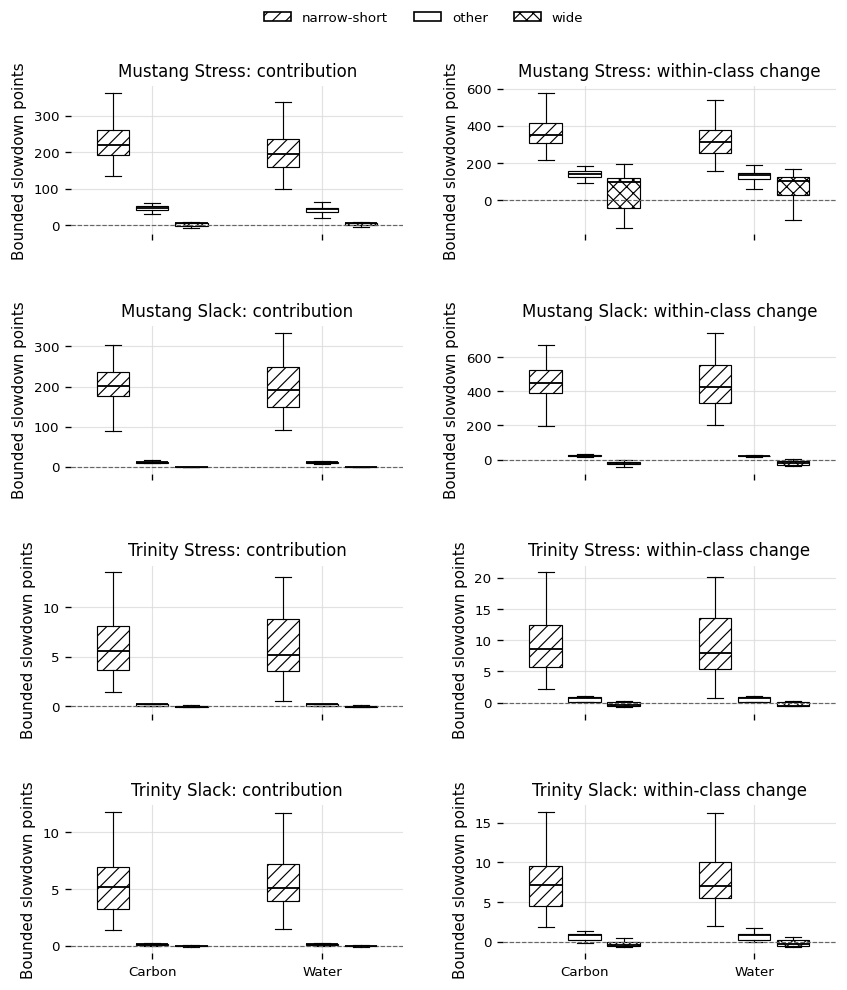

[PosixPath('/home/brunolim4/coding/pibic/experimental-artifacts/analysis/figures/greenfilling_slowdown_by_class.pdf'),
 PosixPath('/home/brunolim4/coding/pibic/experimental-artifacts/analysis/figures/greenfilling_slowdown_by_class.png')]

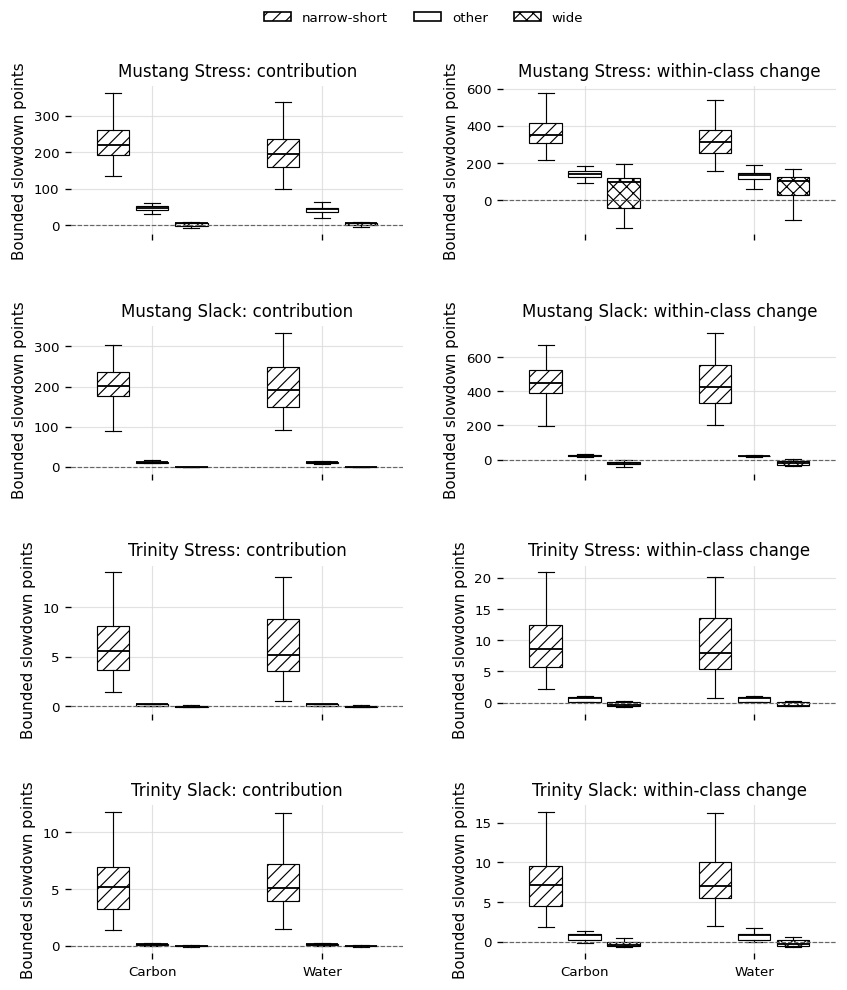

In [15]:
fig = ga.plot_class_effects(by_class)
effect_paths = ga.export_figure(fig, ga.EFFECT_FIGURE_STEM)
display(fig)
effect_paths

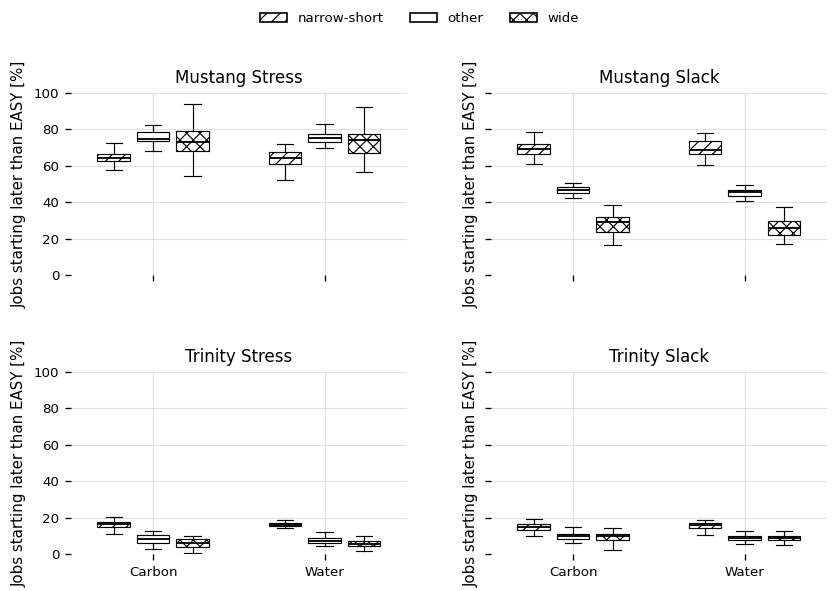

[PosixPath('/home/brunolim4/coding/pibic/experimental-artifacts/analysis/figures/greenfilling_later_starts_by_class.pdf'),
 PosixPath('/home/brunolim4/coding/pibic/experimental-artifacts/analysis/figures/greenfilling_later_starts_by_class.png')]

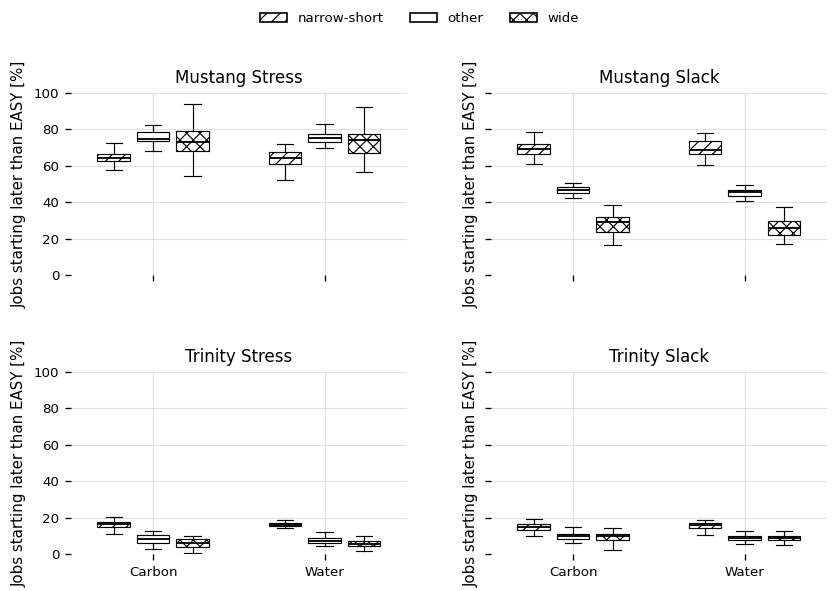

In [16]:
later_fig = ga.plot_later_starts(by_class)
later_paths = ga.export_figure(later_fig, ga.LATER_START_FIGURE_STEM)
display(later_fig)
later_paths

## Interpretation

Narrow-short jobs account for **more than half** of the mean slowdown increase in every window, for all four workloads and both objectives. Their median share of the increase is about **82%** in Mustang stress, **95%** in Mustang slack, and **98–99%** in Trinity. The increase remains positive in every window even when we include only jobs that finish successfully under both schedulers.

How many narrow-short jobs start later differs sharply by cluster. In Mustang, it is about **64%** for stress and **68–69%** for slack. In Trinity, it is only **15–16%**. So the Trinity result does **not** mean most small jobs are delayed: a minority of them accounts for almost all of the mean increase. The delay matters because their execution times are short.

A large effect from short jobs is expected for this metric; our result shows **how large** it is here. The job output tells us when each job started, but not why. We can identify which jobs contribute to the higher mean, not which scheduling decision caused each delay.